In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, RocCurveDisplay


In [4]:
df = pd.read_csv("Loan_Default.csv")
df.head()


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [5]:
df.shape

(148670, 34)

In [6]:
df = df.drop(columns=["ID", "year"], errors="ignore")
num = df.select_dtypes(include=["number"]).columns
for col in num:
    df[col] = df[col].fillna(df[col].median())

cat = df.select_dtypes(include=["object"]).columns
for col in cat:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])

df = df[df["Security_Type"] != "Indriect"]
df = df[df["open_credit"] != "opc"]
df = df[df["construction_type"] != "mh"]
df = df[df["Secured_by"] != "opc"]

df = df.drop(
    columns=["open_credit", "construction_type", "Secured_by", "Security_Type"],
    errors="ignore"
)

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 148081 entries, 0 to 148669
Data columns (total 28 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   loan_limit                 148081 non-null  object 
 1   Gender                     148081 non-null  object 
 2   approv_in_adv              148081 non-null  object 
 3   loan_type                  148081 non-null  object 
 4   loan_purpose               148081 non-null  object 
 5   Credit_Worthiness          148081 non-null  object 
 6   business_or_commercial     148081 non-null  object 
 7   loan_amount                148081 non-null  int64  
 8   rate_of_interest           148081 non-null  float64
 9   Interest_rate_spread       148081 non-null  float64
 10  Upfront_charges            148081 non-null  float64
 11  term                       148081 non-null  float64
 12  Neg_ammortization          148081 non-null  object 
 13  interest_only              148081 

In [7]:
x = df.drop(columns=["Status"])
y = df["Status"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.33,
    random_state=42,
    stratify=y
)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)


Training shape: (99214, 27)
Testing shape: (48867, 27)


Columns checked for outliers:
['loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'property_value', 'income', 'LTV']


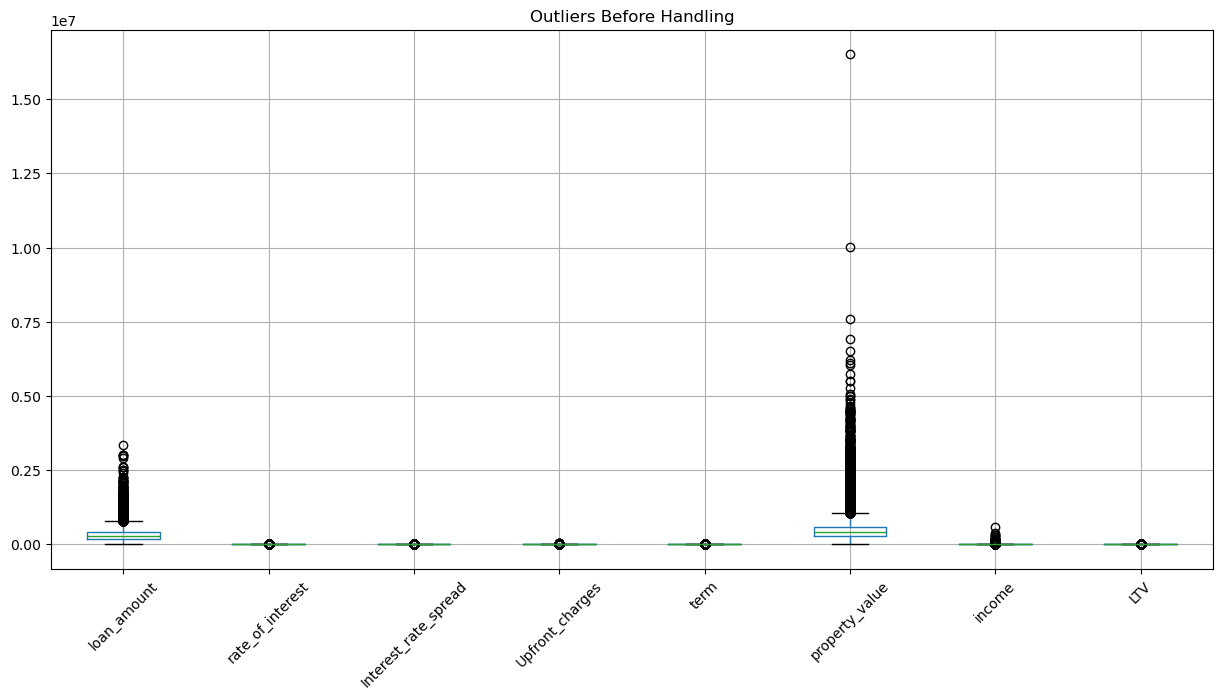

In [8]:
out_cols = [
    "loan_amount",
    "rate_of_interest",
    "Interest_rate_spread",
    "Upfront_charges",
    "term",
    "property_value",
    "income",
    "LTV"
]

out_cols = [col for col in out_cols if col in x_train.columns]

print("Columns checked for outliers:")
print(out_cols)

x_train[out_cols].boxplot(figsize=(15, 7))
plt.xticks(rotation=45)
plt.title("Outliers Before Handling")
plt.show()


In [9]:
def cap_outliers(train, test, cols):
    train = train.copy()
    test = test.copy()

    for col in cols:
        q1 = train[col].quantile(0.25)
        q3 = train[col].quantile(0.75)
        iqr = q3 - q1

        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr

        # Cap extreme values
        train[col] = train[col].clip(lower=low, upper=high)
        test[col] = test[col].clip(lower=low, upper=high)

    return train, test


x_train, x_test = cap_outliers(
    x_train,
    x_test,
    out_cols
)


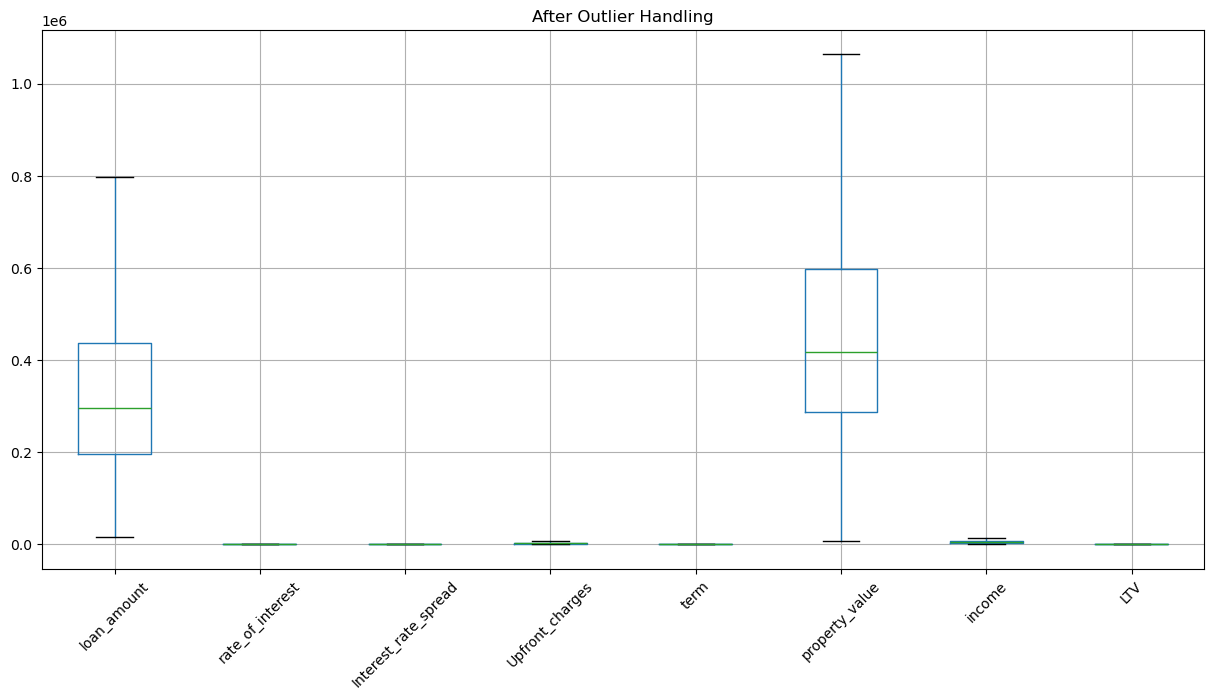

In [10]:
x_train[out_cols].boxplot(figsize=(15, 7))
plt.xticks(rotation=45)
plt.title("After Outlier Handling")
plt.show()


In [11]:
num_cols = x_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = x_train.select_dtypes(include=["object"]).columns.tolist()

prep = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols
        )
    ],
    remainder="passthrough"
)

print("Numerical columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))


Numerical columns: 10
Categorical columns: 17


In [12]:
model = LogisticRegression(
                class_weight="balanced",
                max_iter=1000
            )

model.fit(x_train, y_train)

pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

ValueError: could not convert string to float: 'cf'